# 1. Problem Definition
Breast cancer is the most common cancer among women worldwide. In 2022, it led to approximately 670,000 deaths [1]. Hence, early diagnosis is critical especially since nearly half of cases occur without known risk factors. Medical imaging plays a key role in identifying cancer at its early stages.<br>In this project, I focus on using a deep learning model to classify breast medical images into healthy, non-cancerous and cancerous tumor caregories, in order to support faster and more accurate diagnosis.

[1] WHO. Breast Cancer Factsheet. https://www.who.int/news-room/fact-sheets/detail/breast-cancer

# 2. Resource Collection

This project uses the Breast Ultrasound Images Dataset [2] available on [Kaggle](https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset/data).
Images are categorized into **three classes**:
- **Normal**: Healthy breast tissue with no abnormalities.  
- **Benign**: Non-cancerous findings (e.g., cysts, fibroadenomas) that may appear unusual but are not life-threatening.  
- **Malignant**: Cancerous tumors that may grow and spread, requiring urgent medical attention.

The `sample_data` folder includes one example image from each class.  

[2] Al-Dhabyani W, Gomaa M, Khaled H, Fahmy A. Dataset of breast ultrasound images. *Data in Brief*. 2020;28:104863. DOI: [10.1016/j.dib.2019.104863](https://doi.org/10.1016/j.dib.2019.104863)

# 3. Data Exploration

In this section, we explore the dataset to gain an initial understanding.<br>
First, we display two sample images from each class.<br>
Then, we analyze the class distribution by counting the number of images in each category.
### 3.1. Display sample images

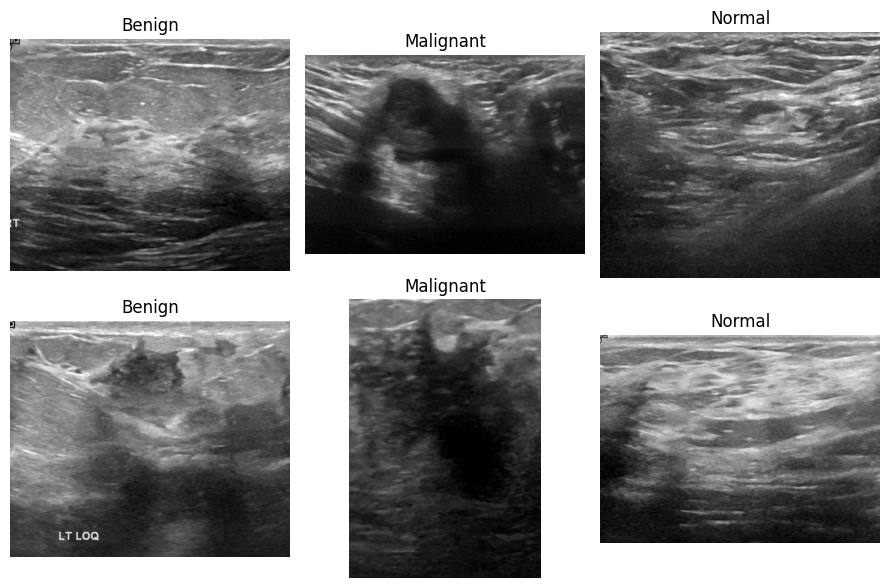

In [1]:
from pathlib import Path
from src.data_exploration import show_samples
dataset_path = Path("data/")
classes = ['benign', 'malignant', 'normal']

show_samples(dataset_path, classes)

### 3.2. Class distribution

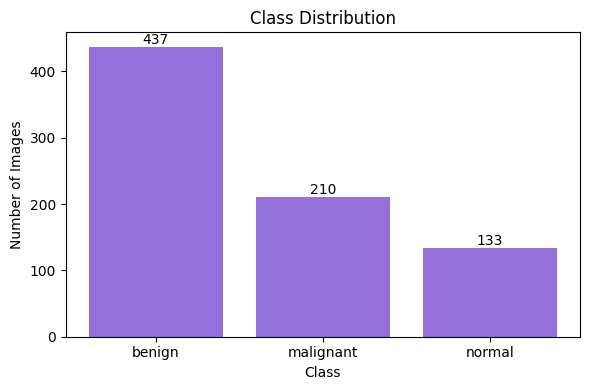

In [2]:
from src.data_exploration import plot_class_distribution

plot_class_distribution(dataset_path, classes)

# 4. Data Handling and Preprocessing

First, I resize all images to the same shape so they can be used in the model.

Since the dataset is small, I use 10-fold cross-validation instead of a fixed train/val split. This helps the model learn from more data and gives better performance estimates. I also set aside 15% of the data as a final test set, used only at the end.

The dataset is imbalanced, so to fix that, I use data augmentation on the smaller classes. Simple transformations like flipping, rotating, and brightness changes help create more training examples and make the model more balanced.

### 4.1. Resizing the images

In [3]:
from src.data_preprocessing import load_ultrasound_images, k_fold_augment
from sklearn.model_selection import train_test_split

IMAGE_SIZE = 224  # depends on the CNN model we choose
X, y = load_ultrasound_images(dataset_path, classes, IMAGE_SIZE)

2026-03-01 12:24:50.077739: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-01 12:24:50.077982: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-01 12:24:50.118425: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-01 12:24:51.134167: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computat

### 4.2. K folds with augmented data splitting

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

augmenter = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)

X_fold, X_test, y_fold, y_test = train_test_split(X, y, test_size=0.15,
                                                  stratify=y, random_state=42)
print(y_fold.shape)
folds = k_fold_augment(X_fold, y_fold, 5, augmenter)

(663,)

🔁 Fold 1/5
[0 1 2]
Class 0 original shape: (530, 224, 224, 3)
Class 0 augmented shape: (296, 224, 224, 3)
Class 1 original shape: (530, 224, 224, 3)
Class 1 augmented shape: (296, 224, 224, 3)
Class 2 original shape: (530, 224, 224, 3)
Class 2 augmented shape: (296, 224, 224, 3)

🔁 Fold 2/5
[0 1 2]
Class 0 original shape: (530, 224, 224, 3)
Class 0 augmented shape: (297, 224, 224, 3)
Class 1 original shape: (530, 224, 224, 3)
Class 1 augmented shape: (297, 224, 224, 3)
Class 2 original shape: (530, 224, 224, 3)
Class 2 augmented shape: (297, 224, 224, 3)

🔁 Fold 3/5
[0 1 2]
Class 0 original shape: (530, 224, 224, 3)
Class 0 augmented shape: (297, 224, 224, 3)
Class 1 original shape: (530, 224, 224, 3)
Class 1 augmented shape: (297, 224, 224, 3)
Class 2 original shape: (530, 224, 224, 3)
Class 2 augmented shape: (297, 224, 224, 3)

🔁 Fold 4/5
[0 1 2]
Class 0 original shape: (531, 224, 224, 3)
Class 0 augmented shape: (297, 224, 224, 3)
Class 1 original shape: (531, 224, 224, 3)


# 6. K-Fold Cross-Validation

To evaluate the model reliably on a small dataset, I use k-fold cross-validation.
The data is split into several folds. For each fold, the model is trained on the training split and evaluated on a different validation split.

For every fold:
- A new model is built and trained from scratch
- Performance is evaluated on the validation data
- Classification metrics and a confusion matrix are computed
## 6.1. Training

Training fold 1/5
(888, 224, 224, 3) (888,)


2026-03-01 12:30:48.945859: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 23s 0us/step
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 51s 834ms/step - accuracy: 0.6622 - f1_m: 0.6792 - loss: 0.8282 - precision_m: 0.6747 - recall_m: 0.6871 - val_accuracy: 0.7143 - val_f1_m: 0.6482 - val_loss: 0.6475 - val_precision_m: 0.6462 - val_recall_m: 0.6539
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 46s 826ms/step - accuracy: 0.8975 - f1_m: 0.9062 - loss: 0.2782 - precision_m: 0.8983 - recall_m: 0.9149 - val_accuracy: 0.7895 - val_f1_m: 0.6853 - val_loss: 0.5292 - val_precision_m: 0.6835 - val_recall_m: 0.6904
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 45s 809ms/step - accuracy: 0.9493 - f1_m: 0.9484 - loss: 0.1677 - precision_m: 0.9365 - recall_m: 0.9618 - val_accuracy: 0.7744 - val_f1_m: 0.6685 - val_loss: 0.5379 - val_precision_m: 0.6769 - val_recall_m: 0.6635
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 39s 694ms/step - accuracy: 0.9831 - f1_m: 0.9822 - loss: 0.0771 - precision_m: 0.9781 - recall_m: 0.9867 - val_accuracy: 0.8045 - val_f1_m: 0.6951 - va

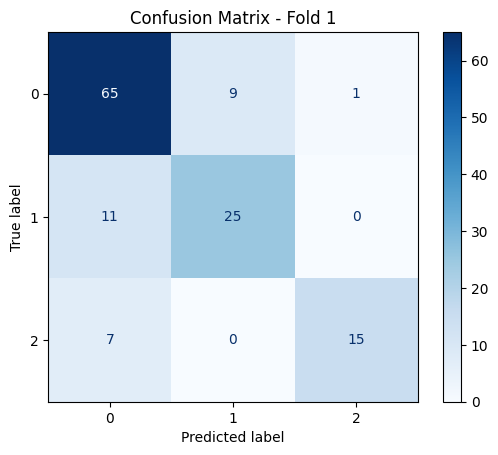

Training fold 2/5
(891, 224, 224, 3) (891,)
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 503ms/step - accuracy: 0.6689 - f1_m: 0.6808 - loss: 0.7858 - precision_m: 0.6749 - recall_m: 0.6882 - val_accuracy: 0.7368 - val_f1_m: 0.6564 - val_loss: 0.6967 - val_precision_m: 0.6477 - val_recall_m: 0.6785
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 486ms/step - accuracy: 0.9214 - f1_m: 0.9267 - loss: 0.2353 - precision_m: 0.9196 - recall_m: 0.9345 - val_accuracy: 0.8271 - val_f1_m: 0.8246 - val_loss: 0.5067 - val_precision_m: 0.8158 - val_recall_m: 0.8388
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 489ms/step - accuracy: 0.9473 - f1_m: 0.9468 - loss: 0.1461 - precision_m: 0.9389 - recall_m: 0.9556 - val_accuracy: 0.8045 - val_f1_m: 0.8320 - val_loss: 0.4703 - val_precision_m: 0.8049 - val_recall_m: 0.8649
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 487ms/step - accuracy: 0.9787 - f1_m: 0.9791 - loss: 0.0792 - precision_m: 0.9754 - recall_m: 0.9832 - val_accuracy: 0.8722 - val_f1_m: 0.8764 - val_loss: 

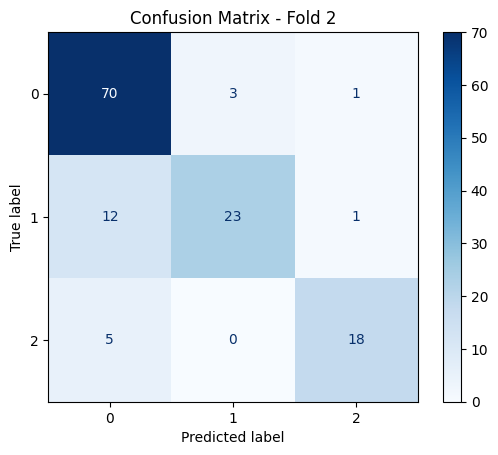

Training fold 3/5
(891, 224, 224, 3) (891,)
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 464ms/step - accuracy: 0.6532 - f1_m: 0.6740 - loss: 0.8237 - precision_m: 0.6627 - recall_m: 0.6883 - val_accuracy: 0.7293 - val_f1_m: 0.6200 - val_loss: 0.6260 - val_precision_m: 0.6822 - val_recall_m: 0.5735
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 483ms/step - accuracy: 0.8833 - f1_m: 0.8898 - loss: 0.3006 - precision_m: 0.8804 - recall_m: 0.9002 - val_accuracy: 0.8045 - val_f1_m: 0.7267 - val_loss: 0.4663 - val_precision_m: 0.7519 - val_recall_m: 0.7047
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 492ms/step - accuracy: 0.9394 - f1_m: 0.9382 - loss: 0.1673 - precision_m: 0.9329 - recall_m: 0.9443 - val_accuracy: 0.8421 - val_f1_m: 0.7478 - val_loss: 0.3843 - val_precision_m: 0.7506 - val_recall_m: 0.7503
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 488ms/step - accuracy: 0.9719 - f1_m: 0.9728 - loss: 0.1054 - precision_m: 0.9651 - recall_m: 0.9813 - val_accuracy: 0.8647 - val_f1_m: 0.7978 - val_loss: 

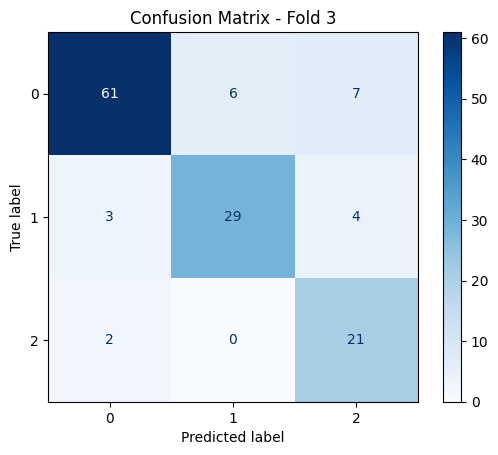

Training fold 4/5
(891, 224, 224, 3) (891,)
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 502ms/step - accuracy: 0.6880 - f1_m: 0.7016 - loss: 0.7363 - precision_m: 0.6976 - recall_m: 0.7073 - val_accuracy: 0.6212 - val_f1_m: 0.4500 - val_loss: 0.8262 - val_precision_m: 0.4094 - val_recall_m: 0.5042
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 487ms/step - accuracy: 0.9046 - f1_m: 0.9072 - loss: 0.2678 - precision_m: 0.8991 - recall_m: 0.9164 - val_accuracy: 0.7955 - val_f1_m: 0.7392 - val_loss: 0.4953 - val_precision_m: 0.7980 - val_recall_m: 0.6939
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 489ms/step - accuracy: 0.9484 - f1_m: 0.9510 - loss: 0.1520 - precision_m: 0.9426 - recall_m: 0.9601 - val_accuracy: 0.8333 - val_f1_m: 0.8207 - val_loss: 0.4366 - val_precision_m: 0.8213 - val_recall_m: 0.8216
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 485ms/step - accuracy: 0.9809 - f1_m: 0.9815 - loss: 0.0823 - precision_m: 0.9778 - recall_m: 0.9856 - val_accuracy: 0.8333 - val_f1_m: 0.8088 - val_loss: 

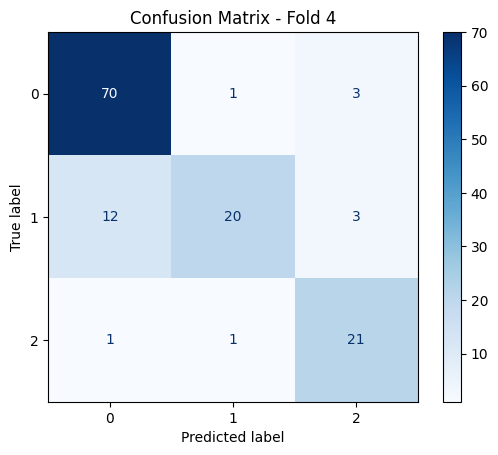

Training fold 5/5
(891, 224, 224, 3) (891,)
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 465ms/step - accuracy: 0.6835 - f1_m: 0.7001 - loss: 0.7774 - precision_m: 0.6977 - recall_m: 0.7047 - val_accuracy: 0.7652 - val_f1_m: 0.6001 - val_loss: 0.5810 - val_precision_m: 0.6221 - val_recall_m: 0.5878
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 449ms/step - accuracy: 0.9068 - f1_m: 0.9120 - loss: 0.2493 - precision_m: 0.9055 - recall_m: 0.9192 - val_accuracy: 0.7955 - val_f1_m: 0.6529 - val_loss: 0.5251 - val_precision_m: 0.6741 - val_recall_m: 0.6363
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 453ms/step - accuracy: 0.9630 - f1_m: 0.9612 - loss: 0.1279 - precision_m: 0.9528 - recall_m: 0.9705 - val_accuracy: 0.7803 - val_f1_m: 0.6621 - val_loss: 0.5324 - val_precision_m: 0.6618 - val_recall_m: 0.6705
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 517ms/step - accuracy: 0.9731 - f1_m: 0.9603 - loss: 0.0877 - precision_m: 0.9553 - recall_m: 0.9657 - val_accuracy: 0.7727 - val_f1_m: 0.6578 - val_loss: 

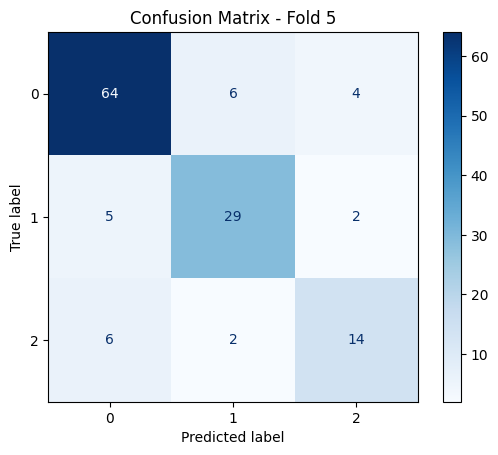

In [6]:
from src.model_development import build_model, make_gradcam_heatmap
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

num_folds = len(folds)
val_scores = []

for fold_idx, (X_train, y_train, X_val, y_val) in enumerate(folds, start=1):
    print(f"Training fold {fold_idx}/{len(folds)}")
    print(X_train.shape, y_train.shape)

    # Ensure correct dtype
    X_train = X_train.astype('float32')
    X_val = X_val.astype('float32')

    # Build model for this fold
    model = build_model()

    # Train model
    model.fit(
        X_train, y_train,
        batch_size=16,
        epochs=20,
        validation_data=(X_val, y_val)
    )
        # Evaluate on validation data
    results = model.evaluate(X_val, y_val)
    val_scores.append(results)
    print(f"Results for fold {fold_idx} : {results}")

    # Predictions
    y_pred_probs = model.predict(X_val)
    y_pred = y_pred_probs.argmax(axis=1)

    # Classification report
    print(classification_report(y_val, y_pred, digits=4))

    # Confusion Matrix
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    cm = confusion_matrix(y_val, y_pred_classes)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - Fold {fold_idx}")
    plt.show()

## 6.2. Cross-Validation Results
After training the model using k-fold cross-validation, the performance is aggregated across all folds.
Reporting the mean and standard deviation allows evaluating both performance and stability of the model across different data splits.

📊 Cross-Validation Performance Summary

loss                : 0.7858 ± 0.2609
compile_metrics     : 0.8220 ± 0.0193


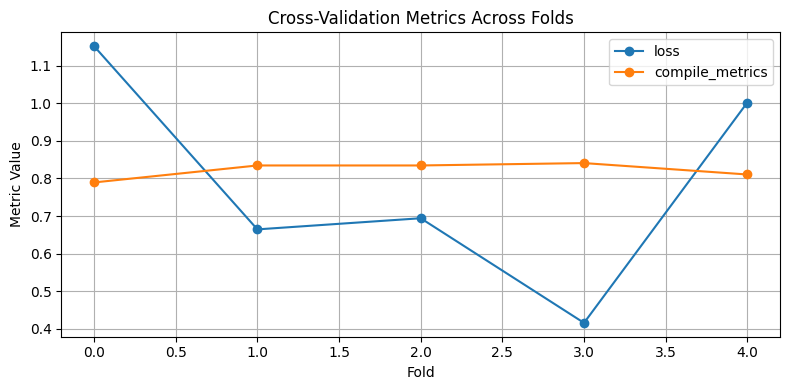

In [7]:
from src.evaluation_metrics import summarize_cv_results, plot_cv_metrics
summarize_cv_results(val_scores, model.metrics_names)
plot_cv_metrics(val_scores, model.metrics_names)

In [8]:
val_scores = np.array(val_scores)
print("val_scores shape:", val_scores.shape)
print("Example fold output:", val_scores[0])

val_scores shape: (5, 5)
Example fold output: [1.15167046 0.78947371 0.76577002 0.71402121 0.73859549]


## 6.3. Discussion
The cross-validation results show consistent performance across folds, indicating good generalization despite the limited dataset size.

Balanced accuracy and macro-averaged metrics were used to account for class imbalance, which is critical in medical imaging tasks.

The model demonstrates particularly strong performance on benign and normal cases, while malignant detection remains acceptable but highlights the importance of recall-focused evaluation.

# 7. Model Training and Final Evaluation
## 7.1. Model Training

The training data is converted to float32 and used to train the ResNet50-based model. Transfer learning is applied by fine-tuning the last layers while keeping most of the backbone frozen. The model is trained for 20 epochs with a batch size of 16 to learn task-specific features for breast ultrasound classification.

In [9]:
X_train = X_fold.astype("float32")
y_train = y_fold.astype("float32")

model = build_model()
model.fit(
    X_train,
    y_train,
    batch_size=16,
    epochs=20,
)


Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 363ms/step - accuracy: 0.6063 - f1_m: 0.5886 - loss: 0.9617 - precision_m: 0.5968 - recall_m: 0.5925
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 356ms/step - accuracy: 0.8356 - f1_m: 0.8158 - loss: 0.4057 - precision_m: 0.8110 - recall_m: 0.8245
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 20s 465ms/step - accuracy: 0.9442 - f1_m: 0.9133 - loss: 0.2069 - precision_m: 0.9107 - recall_m: 0.9193
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 440ms/step - accuracy: 0.9713 - f1_m: 0.9532 - loss: 0.1263 - precision_m: 0.9438 - recall_m: 0.9639
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 431ms/step - accuracy: 0.9774 - f1_m: 0.9529 - loss: 0.1126 - precision_m: 0.9520 - recall_m: 0.9547
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 434ms/step - accuracy: 0.9819 - f1_m: 0.9753 - loss: 0.0883 - precision_m: 0.9722 - recall_m: 0.9790
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 455ms/step - accuracy: 0.9879 - f1_m: 0.9666 - loss: 0.0515 - precision_m: 0.9655 - recall_m: 0.9682

## 7.2. Test Evaluation

The trained model is evaluated on a held-out test set that was not used during training or cross-validation. This provides an unbiased estimate of the model’s real-world performance.

In [ ]:
test_metrics = model.evaluate(
    X_test.astype("float32"),
    y_test,
    verbose=0
)

## 7.3. Grad-CAM Visualization
Grad-CAM is used to visualize which image regions influenced the model’s prediction. The heatmap highlights important areas, and the overlay shows whether the model focused on clinically relevant regions. The true and predicted labels are displayed for comparison.

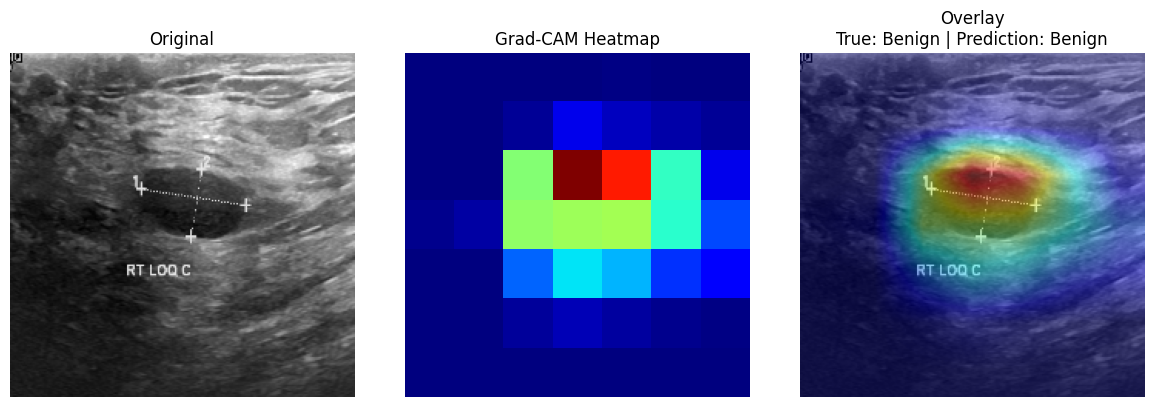

In [ ]:
import cv2
from src.model_development import overlay_gradcam

idx = 4
img = X_test[idx]
true_label = y_test[idx]

prediction = model.predict(np.expand_dims(img, axis=0), verbose=0)
pred_label = np.argmax(prediction)


last_conv_layer_name = "conv5_block3_out"
heatmap = make_gradcam_heatmap(img, model, last_conv_layer_name)

overlay = overlay_gradcam(img, heatmap)


plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"Overlay\nTrue: {classes[true_label]} | Prediction: {classes[pred_label]}")
plt.axis("off")

plt.tight_layout()
plt.show()

## 7.4. Test Set Evaluation
### 7.4.1 Quantitative Metrics
Predictions are generated on the test set and used to compute a classification report, including precision, recall, and F1-score for each class. Balanced accuracy is also calculated to account for class imbalance and provide a fairer evaluation across categories.

In [27]:
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Predictions
y_probs = model.predict(X_test, verbose=0)
y_pred = y_probs.argmax(axis=1)

# Classification report
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Benign", "Malignant", "Normal"],
    digits=4
))

# Additional metrics
bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {bal_acc:.4f}")

Classification Report:
              precision    recall  f1-score   support

      Benign     0.8906    0.8636    0.8769        66
   Malignant     0.8667    0.8387    0.8525        31
      Normal     0.7391    0.8500    0.7907        20

    accuracy                         0.8547       117
   macro avg     0.8321    0.8508    0.8400       117
weighted avg     0.8584    0.8547    0.8557       117

Balanced Accuracy: 0.8508


The model achieved 85.47% accuracy and 85.08% balanced accuracy, indicating stable performance across classes.

Performance is strongest for the Benign class. Malignant recall is slightly lower, which is clinically important since missed malignant cases are critical. The Normal class shows lower precision but good recall.

Overall, results suggest balanced and reliable generalization despite class imbalance.

### 7.4.2. Confusion Matrix
The confusion matrix visualizes correct and incorrect predictions for each class, helping identify systematic errors and clinically critical misclassifications.

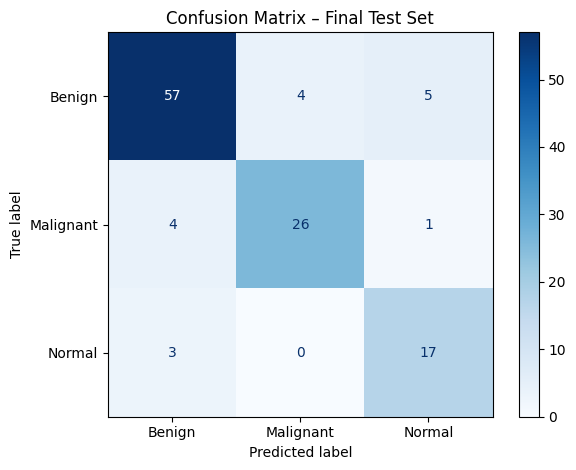

In [28]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant", "Normal"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Final Test Set")
plt.tight_layout()
plt.show()

The confusion matrix shows that most Benign and Normal samples are correctly classified.
Some Malignant cases are misclassified, which is clinically important because missed malignant predictions carry higher risk.

Overall, the model demonstrates good class-wise performance with few critical errors.

## 7.4.3. Final Test Metrics
This block computes detailed quantitative metrics on the test set, including class-wise precision, recall, and F1-score, as well as overall balanced accuracy and macro-averaged scores. These metrics provide a clear summary of the model’s performance across all classes.

In [29]:
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    precision_recall_fscore_support
)

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant", "Normal"],
        digits=4
    )
)

bal_acc = balanced_accuracy_score(y_test, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro"
)

print("\nFinal Test Metrics:")
print(f"Balanced Accuracy : {bal_acc:.4f}")
print(f"Macro Precision   : {precision:.4f}")
print(f"Macro Recall      : {recall:.4f}")
print(f"Macro F1-score    : {f1:.4f}")


Classification Report:
              precision    recall  f1-score   support

      Benign     0.8906    0.8636    0.8769        66
   Malignant     0.8667    0.8387    0.8525        31
      Normal     0.7391    0.8500    0.7907        20

    accuracy                         0.8547       117
   macro avg     0.8321    0.8508    0.8400       117
weighted avg     0.8584    0.8547    0.8557       117


Final Test Metrics:
Balanced Accuracy : 0.8508
Macro Precision   : 0.8321
Macro Recall      : 0.8508
Macro F1-score    : 0.8400


The model achieves 85.5% accuracy and 85.1% balanced accuracy, showing stable overall performance.

Benign and Malignant classes perform well with high precision and recall.

Normal has slightly lower precision but good recall.

Macro-averaged metrics indicate consistent performance across all classes, despite class imbalance.